<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

## Setup imports

In [ ]:
import os
import shutil
import tempfile
import matplotlib.pyplot as plt
import numpy as np

from bioMONAI.data import *
from bioMONAI.core import *
from bioMONAI.metrics import ROCAUCMetric, accuracy
from bioMONAI.datasets import download_file
from bioMONAI.core import Path
from bioMONAI.io import image_reader
from bioMONAI.losses import CrossEntropyLossFlat
from bioMONAI.data import CategoryBlock, parent_label
from bioMONAI.callbacks import SaveModelCallback
from bioMONAI.visualize import plot_metrics

from monai.config import print_config
from monai.networks.nets import DenseNet121
from monai.transforms import (
    EnsureChannelFirstd,
    LoadImaged,
    RandFlipd,
    RandRotated,
    RandZoomd,
    ScaleIntensityd,
)
from monai.utils import set_determinism

print_config()

MONAI version: 1.5.2
Numpy version: 2.4.2
Pytorch version: 2.9.1+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /home/<username>/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.3
scikit-image version: 0.26.0
scipy version: 1.17.0
Pillow version: 12.1.1
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.24.1+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 3.0.0
einops version: 0.8.2
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or

## Setup data directory

You can specify a directory.  
This allows you to save results and reuse downloads.  
If not specified a temporary directory will be used.

In [ ]:
base_directory = '../_data/'
if base_directory is not None:
    os.makedirs(base_directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if base_directory is None else base_directory
print(root_dir)

../../_data/


## Download dataset

The MedNIST dataset was gathered from several sets from [TCIA](https://wiki.cancerimagingarchive.net/display/Public/Data+Usage+Policies+and+Restrictions),
[the RSNA Bone Age Challenge](http://rsnachallenges.cloudapp.net/competitions/4),
and [the NIH Chest X-ray dataset](https://cloud.google.com/healthcare/docs/resources/public-datasets/nih-chest).

The dataset is kindly made available by [Dr. Bradley J. Erickson M.D., Ph.D.](https://www.mayo.edu/research/labs/radiology-informatics/overview) (Department of Radiology, Mayo Clinic)
under the Creative Commons [CC BY-SA 4.0 license](https://creativecommons.org/licenses/by-sa/4.0/).

If you use the MedNIST dataset, please acknowledge the source.

In [ ]:
resource = "https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/MedNIST.tar.gz"
hash = "f2f4881ff8799a170b10a403495f0ce0ad7486491901cde67a647e6627e7f916"
download_file(resource, output_dir=root_dir, hash=hash, extract_dir='.')

Untarring contents of '/home/bm/Documents/bioMONAI/nbs/_data/f8b235cefbf0effb29acd992b838db5a-MedNIST.tar.gz' to '/home/bm/Documents/bioMONAI/nbs/_data/.'


The file has been downloaded and saved to: /home/bm/Documents/bioMONAI/nbs/_data


Change suffix from .jpeg to .jpg (bioio package only accepts .jpg)

In [ ]:
directory = root_dir + 'MedNIST/'
for p in Path(directory).rglob("*.jpeg"):
    p.rename(p.with_suffix(".jpg"))

## Set deterministic training for reproducibility

In [ ]:
set_determinism(seed=0)

## Read image filenames from the dataset folders

First of all, check the dataset files and show some statistics.  
There are 6 folders in the dataset: Hand, AbdomenCT, CXR, ChestCT, BreastMRI, HeadCT,  
which should be used as the labels to train our classification model.

In [ ]:
img_paths = get_images(directory)
class_names = sorted(x for x in os.listdir(directory) if os.path.isdir(os.path.join(directory, x)))
class_map = {c: idx for idx, c in enumerate(class_names)}
num_class = len(class_names)
num_total = len(img_paths)
image_width, image_height = image_reader(img_paths[0]).squeeze().shape
num_each = [len(get_images(directory+class_name)) for class_name in class_names]

print(f"Total image count: {num_total}")
print(f"Image dimensions: {image_width} x {image_height}")
print(f"Label names: {class_names}")
print(f"Label counts: {num_each}")

Total image count: 58954
Image dimensions: 64 x 64
Label names: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']
Label counts: [10000, 8954, 10000, 10000, 10000, 10000]


## Prepare training, validation and test data lists

Randomly select 10% of the dataset as validation and 10% as test.

In [ ]:
train_frac = 0.8
val_frac = 0.1
build_df(img_paths,
          lambda x: class_map[parent_label(x)],
          function_names = ['label'], 
          split=True,
          split_kwargs={ 'train_fraction': train_frac, 
                         'valid_fraction': val_frac,
                         'add_is_valid': True,
                         'data_save_path': directory,
                         'random_seed': 42}
         )

'is_valid' column added to train dataframe for validation samples.
Datasets saved to %s ../../_data/MedNIST/


(                                       filename  label  is_valid
 58881       ../../_data/MedNIST/Hand/009148.jpg      4         0
 17480     ../../_data/MedNIST/HeadCT/004089.jpg      5         0
 33808    ../../_data/MedNIST/ChestCT/008127.jpg      3         0
 15311     ../../_data/MedNIST/HeadCT/002113.jpg      5         0
 47106        ../../_data/MedNIST/CXR/004845.jpg      2         1
 ...                                         ...    ...       ...
 54343       ../../_data/MedNIST/Hand/005306.jpg      4         0
 38158    ../../_data/MedNIST/ChestCT/000772.jpg      3         0
 860    ../../_data/MedNIST/AbdomenCT/005637.jpg      0         0
 15795     ../../_data/MedNIST/HeadCT/006436.jpg      5         0
 56422       ../../_data/MedNIST/Hand/009069.jpg      4         0
 
 [53058 rows x 3 columns],
                                        filename  label
 1246   ../../_data/MedNIST/AbdomenCT/001141.jpg      0
 8331   ../../_data/MedNIST/AbdomenCT/003496.jpg      0
 39949     

## Define MONAI transforms, Dataset and Dataloader to pre-process data

In [ ]:
item_transforms = [
    LoadImaged(keys=["image"], image_only=True),
    EnsureChannelFirstd(keys=["image"], ),
    ScaleIntensityd(keys=["image"], ),
    RandRotated(keys=["image"], range_x=np.pi / 12, prob=0.5, keep_size=True),
    RandFlipd(keys=["image"], spatial_axis=0, prob=0.5),
    RandZoomd(keys=["image"], min_zoom=0.9, max_zoom=1.1, prob=0.5),
]

In [ ]:
data_ops = {
    'x_keys': "image",
    'y_keys': "label",
    'colmap': {'image':'filename'},
    'vocab': class_names,
    'valid_col': 'is_valid',
    'transforms': item_transforms,
    'num_workers': 10,
    'seed': 0, 
    'batch_size': 300,
    'show_summary': True,
}

data = BioDataLoaders.create(
    directory+'/train.csv',
    dataset='monaidataset',
    **data_ops,
    )

test_data = BioDataLoaders.test_dl(
    directory + '/test.csv',
    dataset='monaidataset',
    **data_ops,
    )


Train DataLoader
----------------
Dataset size : 47163
Batch size   : 300
Batches      : 158
Classes      : ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']

Batch structure:
  [0] shape=(300, 1, 64, 64) dtype=torch.float32 ~4.69 MB
  [1] shape=(300,) dtype=torch.int64 ~0.00 MB
Approx batch memory: 4.69 MB

Valid DataLoader
----------------
Dataset size : 5895
Batch size   : 300
Batches      : 20
Classes      : ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']

Batch structure:
  [0] shape=(300, 1, 64, 64) dtype=torch.float32 ~4.69 MB
  [1] shape=(300,) dtype=torch.int64 ~0.00 MB
Approx batch memory: 4.69 MB

Train DataLoader
----------------
Dataset size : 5896
Batch size   : 300
Batches      : 20
Classes      : ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']

Batch structure:
  [0] shape=(300, 1, 64, 64) dtype=torch.float32 ~4.69 MB
  [1] shape=(300,) dtype=torch.int64 ~0.00 MB
Approx batch memory: 4.69 MB


## Randomly pick images from the dataset to visualize and check

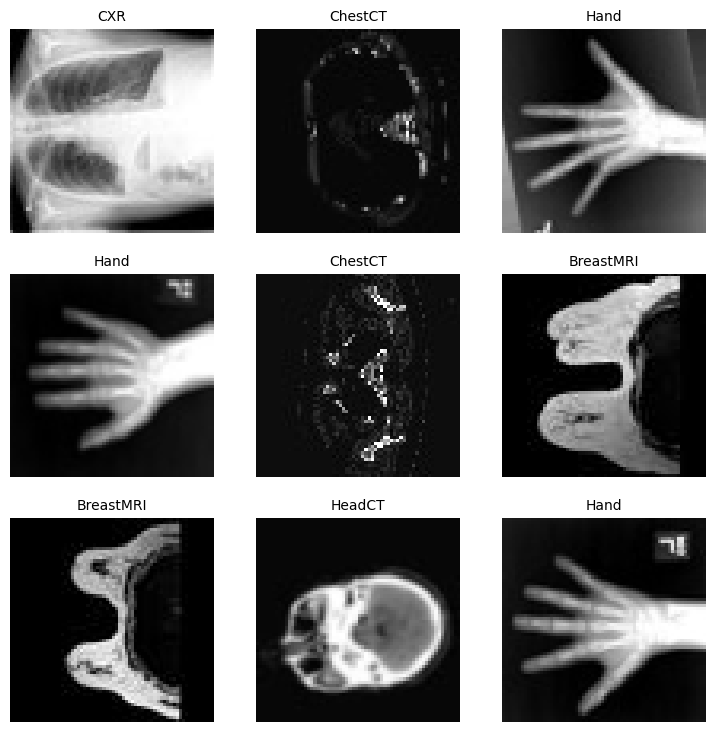

In [ ]:
data.show_batch()

## Define network and optimizer

1. Set learning rate for how much the model is updated per batch.
1. Set total epoch number, as we have shuffle and random transforms, so the training data of every epoch is different.  
And as this is just a get start tutorial, let's just train 4 epochs.  
If train 10 epochs, the model can achieve 100% accuracy on test dataset. 
1. Use DenseNet from MONAI and move to GPU device, this DenseNet can support both 2D and 3D classification tasks.
1. Use Adam optimizer.

In [ ]:
device = get_device()
model = DenseNet121(spatial_dims=2, in_channels=1, out_channels=num_class)
loss_function = CrossEntropyLossFlat()
max_epochs = 4
metrics = [accuracy, ROCAUCMetric(num_classes=num_class)]
save_model_callback = SaveModelCallback(monitor='ROCAUC', fname='best_model.pt')

## Model training

Execute a typical training that run epoch loop and step loop, and do validation after every epoch.  
Will save the model weights to file if got best validation accuracy.

In [ ]:
import torch 
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [ ]:
trainer = fastTrainer(data, model, loss_fn=loss_function, metrics=metrics, show_summary=False, callbacks=[save_model_callback])

epoch,train_loss,valid_loss,accuracy,ROCAUC,time
0,0.013576,0.005503,0.998473,0.999990,00:18
1,0.019909,0.002903,0.999152,0.999999,00:17
2,0.005460,0.003272,0.998643,0.999997,00:17
3,0.004147,0.001790,0.999321,0.999999,00:17


Better model found at epoch 0 with ROCAUC value: 0.9999903617105075.


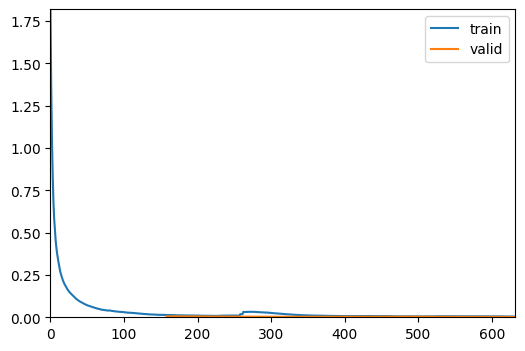

Better model found at epoch 1 with ROCAUC value: 0.9999986207392134.
Better model found at epoch 3 with ROCAUC value: 0.999999425198956.


In [ ]:
trainer.fit(max_epochs)

## Plot the loss and metric

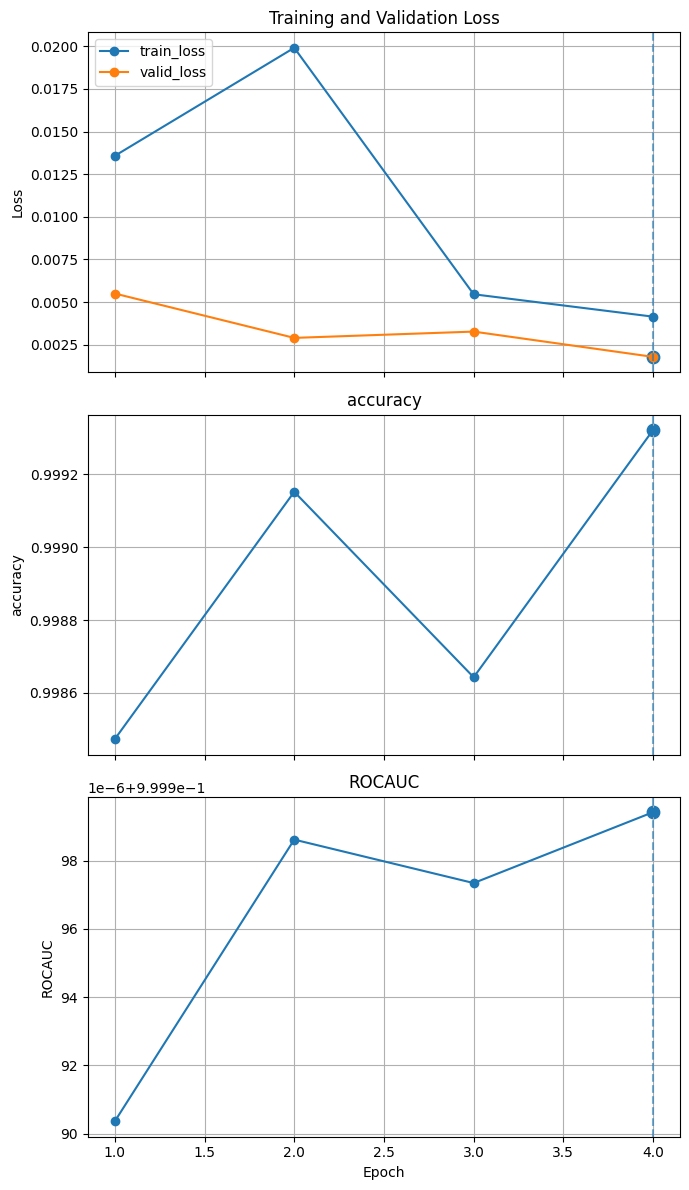

In [ ]:
plot_metrics(trainer)

In [ ]:
torch.cuda.max_memory_allocated() / 1024**2

3254.9599609375

## Evaluate the model on test dataset

After training and validation, we already got the best model on validation test.  
We need to evaluate the model on test dataset to check whether it's robust and not over-fitting.  
We'll use these predictions to generate a classification report.

              precision    recall  f1-score   support

   AbdomenCT       1.00      1.00      1.00       948
   BreastMRI       1.00      1.00      1.00       918
         CXR       1.00      1.00      1.00       932
     ChestCT       1.00      1.00      1.00      1021
        Hand       1.00      1.00      1.00      1017
      HeadCT       1.00      1.00      1.00      1059

    accuracy                           1.00      5895
   macro avg       1.00      1.00      1.00      5895
weighted avg       1.00      1.00      1.00      5895




Most Confused Classes:


,Actual Class,Predicted Class,Count
0,CXR,Hand,2
1,Hand,HeadCT,1
2,HeadCT,AbdomenCT,1


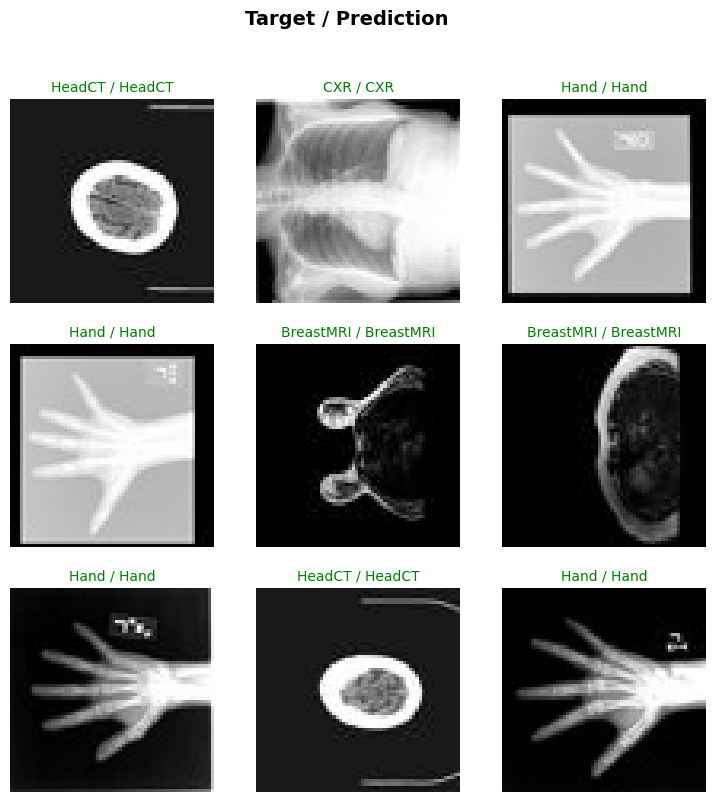

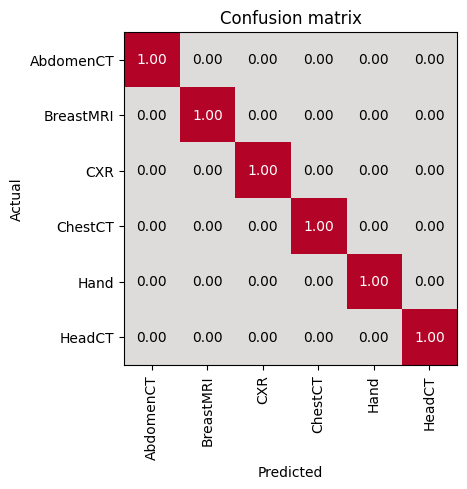

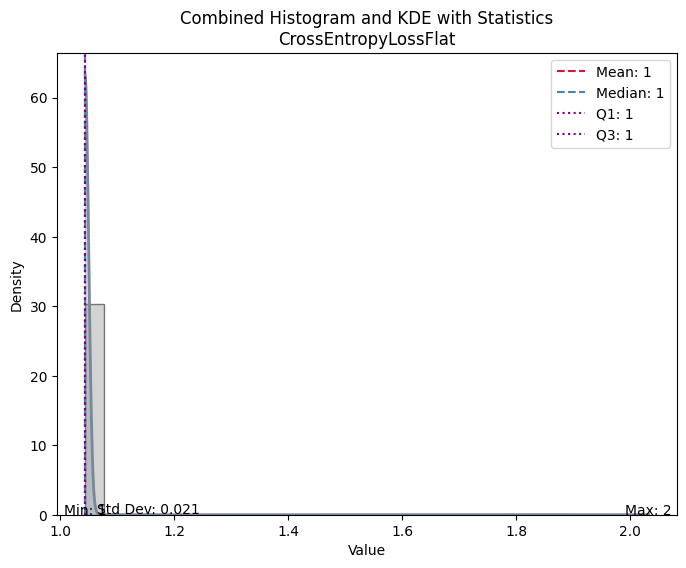

,Value
CrossEntropyLossFlat,
Mean,1.044299
Median,1.043595
Standard Deviation,0.020908
Min,1.043592
Max,2.032166
Q1,1.043593
Q3,1.043603


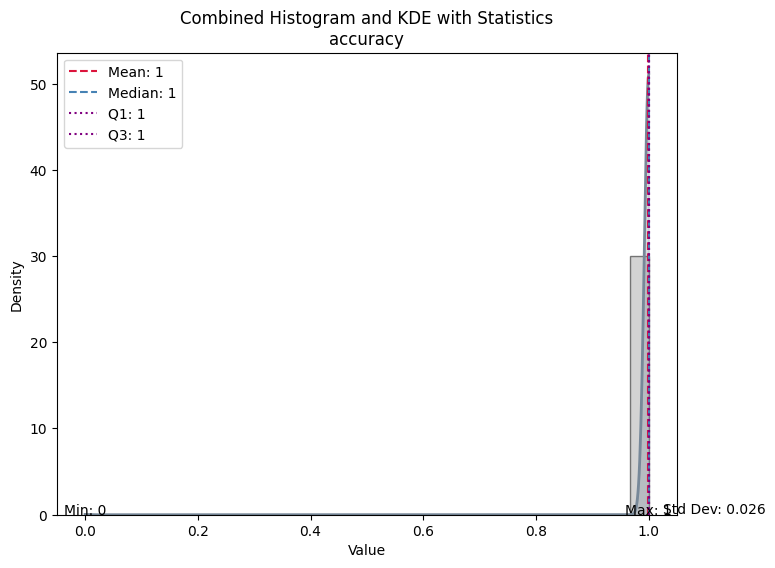

,Value
accuracy,
Mean,0.999321
Median,1.000000
Standard Deviation,0.026040
Min,0.000000
Max,1.000000
Q1,1.000000
Q3,1.000000


In [ ]:
evaluate_classification_model(trainer, test_data, metrics=accuracy, show_graph=True);

## Cleanup data directory

Remove directory if a temporary was used.

In [ ]:
if base_directory is None:
    shutil.rmtree(root_dir)